<a href="https://colab.research.google.com/github/Pranaam19/MSIS-AMA/blob/main/Pruning_and_Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#intentional Overfitting
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

print("Full Tree — Train:", calculate_metrics(y_train, full_tree.predict(X_train)))
print("Full Tree — Test:", calculate_metrics(y_test, full_tree.predict(X_test)))
print("Leaves:", full_tree.get_n_leaves(), "| Depth:", full_tree.get_depth())

Full Tree — Train: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0}
Full Tree — Test: {'Accuracy': 0.9181286549707602, 'Precision': 0.9345794392523364, 'Recall': 0.9345794392523364, 'F1-Score': 0.9345794392523364}
Leaves: 16 | Depth: 6


In [2]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=10,              # 10 folds now works well since we have 569 rows, not 200
    scoring='roc_auc',  # stable metric, not sensitive to small threshold flips
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("Best pre-pruning params:", grid_dt.best_params_)
best_pre_pruned_tree = grid_dt.best_estimator_

print("Pre-Pruned — Train:", calculate_metrics(y_train, best_pre_pruned_tree.predict(X_train)))
print("Pre-Pruned — Test:", calculate_metrics(y_test, best_pre_pruned_tree.predict(X_test)))
print("Leaves:", best_pre_pruned_tree.get_n_leaves(), "| Depth:", best_pre_pruned_tree.get_depth())

Best pre-pruning params: {'max_depth': 3, 'min_samples_leaf': 20, 'min_samples_split': 2}
Pre-Pruned — Train: {'Accuracy': 0.957286432160804, 'Precision': 0.983402489626556, 'Recall': 0.948, 'F1-Score': 0.9653767820773931}
Pre-Pruned — Test: {'Accuracy': 0.9181286549707602, 'Precision': 0.9428571428571428, 'Recall': 0.9252336448598131, 'F1-Score': 0.9339622641509434}
Leaves: 5 | Depth: 3


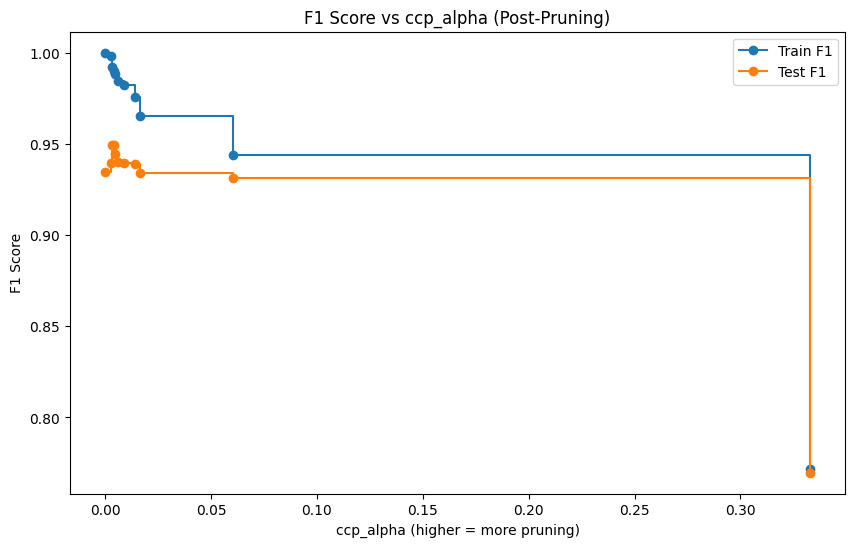

Best ccp_alpha: 0.0029528585562200657
Post-Pruned — Train: {'Accuracy': 0.9899497487437185, 'Precision': 0.984251968503937, 'Recall': 1.0, 'F1-Score': 0.9920634920634921}
Post-Pruned — Test: {'Accuracy': 0.935672514619883, 'Precision': 0.9363636363636364, 'Recall': 0.9626168224299065, 'F1-Score': 0.9493087557603687}
Leaves: 9 | Depth: 4


In [5]:
# Grow the full tree fresh (you already have this as full_tree from before)
import numpy as np
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

trees = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    trees.append(clf)

train_scores = [f1_score(y_train, t.predict(X_train)) for t in trees]
test_scores  = [f1_score(y_test, t.predict(X_test)) for t in trees]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train F1', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label='Test F1', drawstyle="steps-post")
plt.xlabel("ccp_alpha (higher = more pruning)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs ccp_alpha (Post-Pruning)")
plt.legend()
plt.show()

best_alpha = ccp_alphas[np.argmax(test_scores)]
print("Best ccp_alpha:", best_alpha)

best_post_pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_post_pruned_tree.fit(X_train, y_train)

print("Post-Pruned — Train:", calculate_metrics(y_train, best_post_pruned_tree.predict(X_train)))
print("Post-Pruned — Test:", calculate_metrics(y_test, best_post_pruned_tree.predict(X_test)))
print("Leaves:", best_post_pruned_tree.get_n_leaves(), "| Depth:", best_post_pruned_tree.get_depth())

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

lr_l2 = LogisticRegression(penalty='l2', max_iter=10000, random_state=42)  # L2 is sklearn's default
lr_l2.fit(X_train_scaled, y_train)

print("Logistic (L2/Ridge) — Train:", calculate_metrics(y_train, lr_l2.predict(X_train_scaled)))
print("Logistic (L2/Ridge) — Test:", calculate_metrics(y_test, lr_l2.predict(X_test_scaled)))

Logistic (L2/Ridge) — Train: {'Accuracy': 0.9874371859296482, 'Precision': 0.9841897233201581, 'Recall': 0.996, 'F1-Score': 0.9900596421471173}
Logistic (L2/Ridge) — Test: {'Accuracy': 0.9883040935672515, 'Precision': 0.9906542056074766, 'Recall': 0.9906542056074766, 'F1-Score': 0.9906542056074766}


In [8]:
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000, random_state=42)
lr_l1.fit(X_train_scaled, y_train)

print("Logistic (L1/Lasso) — Train:", calculate_metrics(y_train, lr_l1.predict(X_train_scaled)))
print("Logistic (L1/Lasso) — Test:", calculate_metrics(y_test, lr_l1.predict(X_test_scaled)))

Logistic (L1/Lasso) — Train: {'Accuracy': 0.9874371859296482, 'Precision': 0.9841897233201581, 'Recall': 0.996, 'F1-Score': 0.9900596421471173}
Logistic (L1/Lasso) — Test: {'Accuracy': 0.9766081871345029, 'Precision': 0.9724770642201835, 'Recall': 0.9906542056074766, 'F1-Score': 0.9814814814814815}


In [9]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "L2 (Ridge) Coef": lr_l2.coef_[0],
    "L1 (Lasso) Coef": lr_l1.coef_[0]
})
print(coef_df)

zeroed_out = (coef_df["L1 (Lasso) Coef"] == 0).sum()
print(f"\nLasso zeroed out {zeroed_out} of {len(X.columns)} features")

                    Feature  L2 (Ridge) Coef  L1 (Lasso) Coef
0               mean radius        -0.494999         0.000000
1              mean texture        -0.459795        -0.108534
2            mean perimeter        -0.459783         0.000000
3                 mean area        -0.549840         0.000000
4           mean smoothness        -0.167243         0.000000
5          mean compactness         0.652655         0.000000
6            mean concavity        -0.532601         0.000000
7       mean concave points        -0.630654        -0.195086
8             mean symmetry        -0.113813         0.000000
9    mean fractal dimension         0.036185         0.000000
10             radius error        -0.886370        -0.108042
11            texture error         0.367761         0.181537
12          perimeter error        -0.204988         0.000000
13               area error        -0.937493        -1.737427
14         smoothness error        -0.185018        -0.154246
15      